# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## CO-OCCURENCE GRAPH ANALYSIS

This notebook demonstrates how to use the Python extension `xopt` to solve instances of the p-median problem with the `kmedoids` and `tspmed` algorithms.

### SETTING THE ENVIRONMENT

Importing the libraries:

In [1]:
import sys

from pathlib import Path

parent_path = Path().resolve().parent

if str(parent_path) not in sys.path:
    sys.path.insert(0, str(parent_path))

In [2]:
import pymedian

import numpy    as np
import networkx as nx
import seaborn  as sns
import matplotlib.pyplot as plt

from networkx.algorithms import community, betweenness_centrality

This cell locates the "instances" folder in the project root and counts how many p-median instance files exist:

In [3]:
ROOT          = Path.cwd().resolve().parent
INSTANCES_DIR = ROOT / "instances"

if not INSTANCES_DIR.exists():
    raise FileNotFoundError(f"Instances folder not found: {INSTANCES_DIR}")

print(f"Total number of p-median instances: {len(list(INSTANCES_DIR.glob('pmed[0-9]*.txt')))}")

Total number of p-median instances: 40


### APPLYING

We selected a few classic p-median instances and recorded the results obtained:

In [4]:
instance      = "pmed11.txt"
instance_path = str(INSTANCES_DIR / instance)

summary, details = pymedian.solve_pmedian(instance_path,
                                          restarts=8 ,
                                          max_iter=25,
                                          factor  =2 )

best_facilities = [
    idx - 1
    for idx in summary["tspmed_facilities"]
]


print(f"Instance {summary['instance'][:-4]} ({summary['p']}-{summary['n']})")

print()
print(f"  K-Medoids ({summary['kmedoids_cost']}): {summary['medoids'          ][:10]}")
print(f"  TSPMED    ({summary['tspmed_cost'  ]}): {summary['tspmed_facilities'][:10]}")

print()
print(f"Obs.: Distinct solutions recorded in long term memory is {summary['long_term_mem']}!")

Instance /home/rei-luisinho/xopt/instances/pmed11 (5-300)

  K-Medoids (7696.0): [201, 98, 24, 167, 31]
  TSPMED    (7696.0): [201, 98, 24, 167, 31]

Obs.: Distinct solutions recorded in long term memory is 838!


### FACILITY CO-OCCURRENCE NETWORK ACROSS NEAR-OPTIMAL SOLUTIONS

To better understand the structural patterns emerging from the long-term memory solutions, we construct a **facility co-occurrence adjacency matrix**. Each entry $(i, j)$ represents how many times facilities *i* and *j* were simultaneously selected across all stored solutions. This allows us to:

- Identify **strong facility pairings** that frequently appear together  
- Detect potential **structural dependencies or complementarities**  
- Reveal clusters of facilities that characterize near-optimal regions of the solution space  
- Provide a more interpretable view of the solution landscape beyond individual optimal solutions  

The resulting heatmap offers a visual representation of the collective behavior of facilities across the near-optimal solution set.

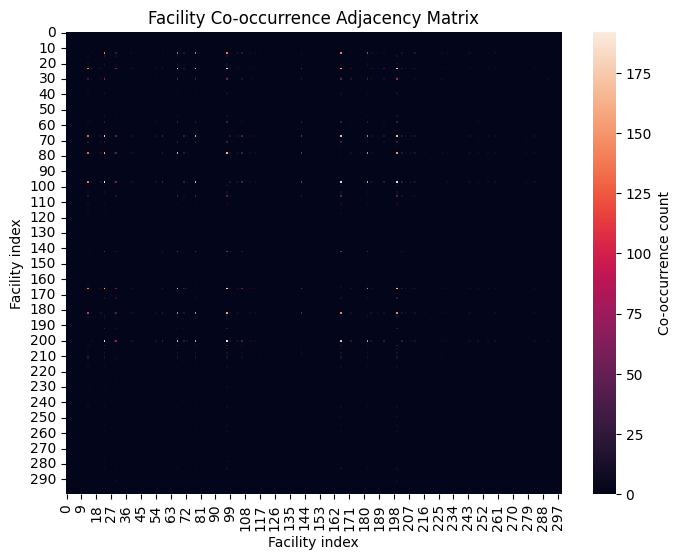

In [5]:
matrix = np.vstack(
    [
        np.array(sol["facilities"])
        for sol in details["long_term_memory"]
    ]
)
costs  = np.array(
    [
        sol["cost"]
        for sol in details["long_term_memory"]
    ],
    dtype=float
)

adjacency_matrix = np.zeros(
    (
        summary['n'],
        summary['n']
    ),
    dtype=int
)

for sol in details["long_term_memory"]:
    facilities       = np.array(sol["facilities"])
    facility_indices = np.where(facilities  ==  1)[0]

    for i in range(len(facility_indices)):
        for j in range(i + 1, len(facility_indices)):
            idx_i = facility_indices[i]
            idx_j = facility_indices[j]

            adjacency_matrix[idx_i, idx_j] += 1
            adjacency_matrix[idx_j, idx_i] += 1


plt.figure(figsize=(8, 6))

sns.heatmap(
    adjacency_matrix, cbar_kws={'label': 'Co-occurrence count'}
)

plt.title ("Facility Co-occurrence Adjacency Matrix")
plt.xlabel("Facility index")
plt.ylabel("Facility index")

plt.show()

#### GREEDY MODULARITY COMMUNITY DETECTION

In this step, we convert the **facility co-occurrence adjacency matrix** into a **weighted, undirected graph**:

- Each **node** represents a facility (indexed from `0` to `n-1`);
- An **edge** between facilities *(i, j)* exists if they co-occur in at least one solution;
- The edge **weight** equals the number of co-occurrences, so stronger links correspond to pairs that appear together more frequently.

We then apply **greedy modularity community detection** (Clauset–Newman–Moore) to partition the graph into **communities**. Each community is a group of facilities that tends to co-occur more **within the group** than with facilities outside the group.

For each detected community, we report:

- The number of facilities in the group;
- A short list of facility indices;
- The **average internal co-occurrence strength** (mean edge weight among connected facility pairs inside the community).

These communities can be interpreted as **recurring facility modules** that characterize different near-optimal regions of the solution space.

In [6]:
G = nx.Graph()

G.add_nodes_from(range(summary['n']))

for i in range(summary['n']):
    for j in range(i + 1, summary['n']):
        if adjacency_matrix[i, j] > 0:
            G.add_edge(i, j, weight=adjacency_matrix[i, j])


communities = list(community.greedy_modularity_communities(G))

print(f"Greedy modularity found {len(communities)} communities!")

Greedy modularity found 244 communities!


In [7]:
best_set = set(best_facilities)

filtered = []

for idx, comm in enumerate(communities):
    if len(comm) <= 1:
        continue

    facilities_in_comm = sorted(list(comm))
    best_in_comm       = sorted(list(best_set.intersection(comm)))

    avg_cooccurrence = np.mean([
        adjacency_matrix[i, j]
        for i in facilities_in_comm
        for j in facilities_in_comm
        if i < j and adjacency_matrix[i, j] > 0
    ])

    filtered.append(
        (
            idx               ,
            facilities_in_comm,
            best_in_comm      ,
            avg_cooccurrence  ,
        )
    )

print(f"Communities shown (size > 1): {len(filtered)}")
print()

for idx, size, best_in_comm, cooccurrence in filtered:
    best_show = ", ".join(map(str, best_in_comm))

    print(f"Community {idx}:"      )
    print(f"{len(size)} facilities")
    print(f"  Avg co-occurrence of {cooccurrence:.2f}"       )
    print(f"  Best facilities in this community: {best_show}")

    print()


best_facilities_sorted = sorted(best_set)


print("*** Best solution ***")
print(f"  Count: {len(best_facilities_sorted)}")
print(f"  Facilities: {', '.join(map(str, best_facilities_sorted))}")

Communities shown (size > 1): 3

Community 0:
24 facilities
  Avg co-occurrence of 16.01
  Best facilities in this community: 23, 166

Community 1:
19 facilities
  Avg co-occurrence of 10.73
  Best facilities in this community: 97

Community 2:
16 facilities
  Avg co-occurrence of 12.00
  Best facilities in this community: 30, 200

*** Best solution ***
  Count: 5
  Facilities: 23, 30, 97, 166, 200


All facilities selected in the best solution are contained within the detected multi-node communities. Each of these facilities appears in one of the identified communities (size > 1), indicating that the optimal configuration is fully supported by structurally cohesive co-occurrence modules.

This suggests that the best solution is not composed of isolated facilities, but rather emerges from strongly connected community structures in the solution landscape.

#### ANTI-COMMUNITIES (MAX-p-CUT)

In this analysis, we seek a **multipartite structure**: groups with **low internal connectivity** and **high external connectivity**. This objective is naturally formulated as a **Max-p-Cut (Max-k-Cut)** problem, which partitions the nodes into `p` groups to **maximize the total weight of edges between groups**. Since the total edge weight of the graph is fixed, maximizing the cut is equivalent to minimizing the total weight of edges within groups.

In [8]:
p = 5

n_restarts = 30
max_iter   = 2000
seed       = 42


A = np.asarray(
    adjacency_matrix, dtype=float
).copy()

n = A.shape[0]

In [9]:
def _random_labels(n, p, rng):
    labels = rng.integers(0, p, size=n)

    if n >= p:
        perm             = rng.permutation(n)
        labels[perm[:p]] = np .arange(p)

    return labels

def _group_sums(A, labels, p):
    n = A.shape[0]

    sums = np.zeros(
        (n, p), dtype=float
    )

    for g in range(p):
        members = labels == g

        if np.any(members):
            sums[:, g] = A[:, members].sum(axis=1)

    return sums


def partition_weights(labels, A):
    same = labels[:, None] == labels[None, :]

    internal = float(np.triu(A * same, 1).sum())
    total    = float(np.triu(A, 1).sum())

    cut = total - internal

    return cut, internal


def max_p_cut_local_search(
    A,
    p,
    n_restarts=20  ,
    max_iter  =2000,
    seed      =42
):
    A = np.asarray(A, dtype=float)

    n = A.shape[0]
    p = int(p)

    if p > n:
        p = n

    n_restarts = max(1, int(n_restarts))
    max_iter   = max(1, int(max_iter  ))

    total_weight = float(np.triu(A, 1).sum() )
    rng          = np.random.default_rng(seed)

    best_cut      = -np.inf
    best_internal =  np.inf
    best_labels   = None

    for _ in range(n_restarts):
        labels = _random_labels(n, p     , rng)
        sums   = _group_sums   (A, labels, p  )

        internal = float(
            np.triu(
                A * (labels[:, None] == labels[None, :]), 1
            ).sum()
        )
        cut      = total_weight - internal

        for _ in range(max_iter):
            improved = False

            for node in rng.permutation(n):
                old_group = labels[node]

                gains            = sums[node, old_group] - sums[node, :]
                gains[old_group] = -np.inf

                new_group = int  (np.argmax(gains))
                gain      = float(gains[new_group])

                if gain > 1e-12:
                    labels[node] = new_group

                    cut += gain

                    sums[:, old_group] -= A[:, node]
                    sums[:, new_group] += A[:, node]

                    improved = True

            if not improved:
                break

        internal = total_weight - cut

        if cut > best_cut + 1e-12:
            best_cut      = float(cut     )
            best_internal = float(internal)
            best_labels = labels.copy()

    return best_labels, best_cut, best_internal


def internal_density(labels, A):
    labels = np.asarray(labels)

    _, internal = partition_weights(labels, A)

    p_eff = int(labels.max()) + 1
    sizes = np.bincount(labels, minlength=p_eff)

    possible = float(
        np.sum(sizes * (sizes - 1) / 2.0)
    )

    if possible <= 0:
        return 0.0

    return internal / possible


def external_density(labels, A):
    labels = np.asarray(labels)

    cut, _ = partition_weights(labels, A)

    n           = len(labels)
    total_pairs = float(n * (n - 1) / 2.0)

    p_eff = int(labels.max()) + 1
    sizes = np.bincount(labels, minlength=p_eff)

    internal_pairs = float(np.sum(sizes * (sizes - 1) / 2.0))
    external_pairs = total_pairs - internal_pairs

    if external_pairs <= 0:
        return 0.0

    return cut / external_pairs


def cluster_delta_stats(labels, A, p):
    labels = np.asarray(labels)

    rows = []

    for g in range(p):
        members = np.where(labels == g)[0]
        size    = int(members.size)

        if size == 0:
            rows.append(
                {
                    'cluster'   : g,
                    'size'      : 0,
                    'delta_in'  : 0.0,
                    'delta_out' : 0.0,
                    'score'     : 0.0,
                }
            )

            continue

        inside  = A[np.ix_(members, members    )]
        outside = A[np.ix_(members, labels != g)]

        internal_weight = float(inside .sum() / 2.0)
        external_weight = float(outside.sum())

        delta_in  = (2.0 * internal_weight) / size
        delta_out = external_weight         / size

        score = delta_out / (delta_in + 1e-9)

        rows.append(
            {
                'cluster'   : g   ,
                'size'      : size,
                'delta_in'  : float(delta_in ),
                'delta_out' : float(delta_out),
                'score'     : float(score    ),
            }
        )

    return rows

In [10]:
labels, cut_weight, internal_weight = max_p_cut_local_search(
    A,
    p,
    n_restarts=n_restarts,
    max_iter  =max_iter  ,
    seed      =seed      ,
)

fraction_cut  = cut_weight / (cut_weight + internal_weight + 1e-12)
cluster_sizes = np.bincount(labels, minlength=p)


print(f"=== Max-p-Cut Local Search (p = {p}) ===")
print()

print(f"Fraction cut     = {fraction_cut*100:.2f}%")
print(f"Internal density = {internal_density(labels, A)*100:.2f}%")
print(f"External density = {external_density(labels, A)*100:.2f}%")

print()
print("Cluster sizes:")
for c in range(p):
    print(f"  Cluster {c}: {int(cluster_sizes[c])} nodes")

=== Max-p-Cut Local Search (p = 5) ===

Fraction cut     = 99.56%
Internal density = 0.40%
External density = 23.47%

Cluster sizes:
  Cluster 0: 80 nodes
  Cluster 1: 41 nodes
  Cluster 2: 66 nodes
  Cluster 3: 63 nodes
  Cluster 4: 50 nodes


In [11]:
print("Best facilities clusters:")

for f in sorted(best_facilities):
    print(f"  Facility {f:3d} -> Cluster {int(labels[f])}")

Best facilities clusters:
  Facility  23 -> Cluster 4
  Facility  30 -> Cluster 0
  Facility  97 -> Cluster 2
  Facility 166 -> Cluster 3
  Facility 200 -> Cluster 1


The selected `best_facilities` are distributed across **five distinct clusters**. This pattern indicates that the best-performing facilities are **structurally diverse**, spanning different regions of the multipartite partition rather than concentrating within a single cluster.

Such dispersion suggests that high-quality solutions leverage facilities with **complementary structural roles**, reinforcing the intended multipartite structure: strong interactions across clusters and limited redundancy within the same cluster.

#### K-CORE DECOMPOSITION

In this section, we analyze the structural hierarchy of the facility co-occurrence network using **k-core decomposition**. K-core decomposition reveals the **nested core-periphery structure** of the network. A facility belongs to the *k-core* if it is connected to at least *k* other facilities that are themselves similarly well-connected.

This allows us to:

- Identify **structurally central facilities** within the solution landscape;
- Distinguish between **core and peripheral nodes**;
- Assess whether the best solution lies in the **deep structural nucleus** of the co-occurrence graph;
- Reveal hierarchical robustness patterns in the network.

Higher k-core values indicate facilities embedded in dense, mutually connected regions of the solution space, suggesting structural importance across near-optimal solutions.

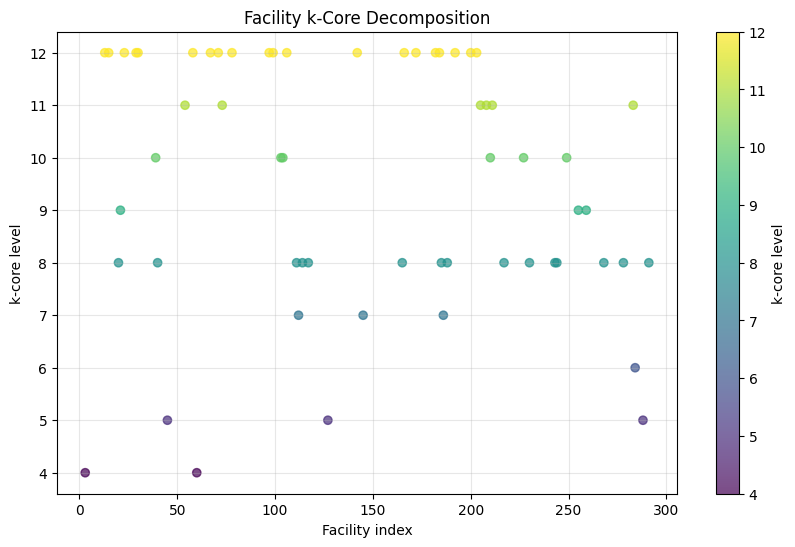

In [12]:
G_binary = nx.Graph()

G_binary.add_nodes_from(range(summary['n']))

for i in range(summary['n']):
    for j in range(i + 1, summary['n']):
        if adjacency_matrix[i, j] > 0:
            G_binary.add_edge(i, j)

k_cores       = nx.core_number(G_binary)
k_core_values = np.array(
    [
        k_cores[i]
        for i in range(summary['n'])
    ]
)

mask = k_core_values >= 2

filtered_indices  = np.arange(summary['n'])[mask]
filtered_k_values = k_core_values          [mask]


plt.figure(figsize=(10, 6))

plt.scatter(
    filtered_indices       ,
    filtered_k_values      ,
    c    =filtered_k_values,
    cmap ='viridis',
    alpha=0.7      ,
)

plt.xlabel("Facility index")
plt.ylabel("k-core level"  )
plt.title ("Facility k-Core Decomposition")

plt.colorbar(label='k-core level')
plt.grid    (True, alpha=0.3)

plt.show()

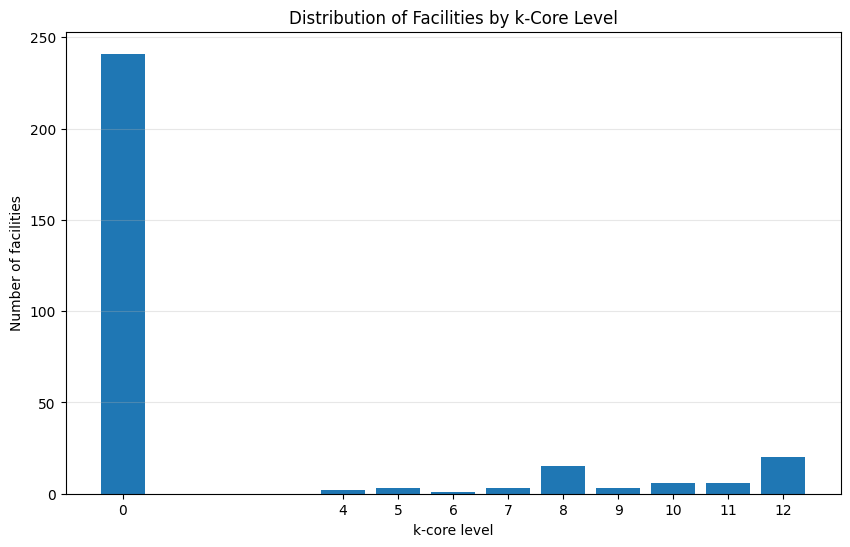

In [13]:
core_levels = sorted(set(k_cores.values()))

counts = [
    list(
        k_cores.values()
    ).count(k)
    for k in core_levels
]


plt.figure(figsize=(10, 6))

plt.bar(core_levels, counts)

plt.xlabel("k-core level"        )
plt.ylabel("Number of facilities")
plt.title ("Distribution of Facilities by k-Core Level")

plt.xticks(core_levels)
plt.grid  (axis='y', alpha=0.3)

plt.show()

In [14]:
print("K-Core Levels of Best Solution Facilities:")
print()

best_set = set(best_facilities)

best_by_core = {}

for f in best_set:
    k = k_cores[f]
    best_by_core.setdefault(k, []).append(f)

for k in sorted(best_by_core.keys()):
    facilities = sorted(best_by_core[k])

    print(f"K-core {k}: {len(facilities)} best facilities")
    print(f"  Facilities: {', '.join(map(str, facilities))}")
    print()

K-Core Levels of Best Solution Facilities:

K-core 12: 5 best facilities
  Facilities: 23, 30, 97, 166, 200



All facilities selected in the best solution belong to the **highest k-core level** of the network, this result has an important structural meaning.

In a k-core decomposition, nodes in higher cores are those that are embedded in densely interconnected regions of the graph. A facility with the maximum k-core value:

- Is connected to many other facilities that are themselves highly connected;
- Belongs to the deepest structural nucleus of the co-occurrence network;
- Is not a peripheral or weakly supported component.

Since **all best-solution facilities lie in the highest k-core**, this indicates that the optimal configuration is entirely composed of structurally central facilities. This suggests that:

- The best solution is not built from isolated or rare facility combinations;
- It emerges from the **core structural backbone** of the near-optimal solution space;
- The optimal configuration is supported by strongly recurrent co-occurrence patterns.

In other words, the best solution resides in the **most cohesive and robust region** of the facility interaction network. This provides evidence that the optimization process converges toward structurally stable modules rather than peripheral or unstable combinations.

#### STRENGTH CENTRALITY

This code computes and analyzes the **strength centrality** of each facility in the co-occurrence network. In a weighted graph, the **strength** of a node is the sum of the weights of all edges connected to it. Here, edge weights represent how many times two facilities co-occur across solutions.

Mathematically:

$
\text{strength}(i) = \sum_j A_{ij}
$

Where:

$ A_{ij} $ is the co-occurrence count between facilities *i* and *j*.

Thus, a facility with high strength centrality:

- Frequently co-occurs with many other facilities;
- Is strongly embedded in the solution landscape;
- Plays a structurally influential role across near-optimal solutions.

In [15]:
strength_centrality = np.sum    (adjacency_matrix, axis=1)
sorted_indices      = np.argsort(strength_centrality)[::-1]


print("Top 15 facilities by strength centrality:")
print()

for rank, idx in enumerate(sorted_indices[:15], 1):
    star = "*" if idx in best_set else " "

    print(f"{rank:2d}. Facility {idx:3d}{star}: {strength_centrality[idx]:5.0f}")

Top 15 facilities by strength centrality:

 1. Facility  97*:  1628
 2. Facility  23*:  1612
 3. Facility 200*:  1572
 4. Facility 166*:  1512
 5. Facility  67 :  1488
 6. Facility  78 :  1376
 7. Facility 182 :  1236
 8. Facility  13 :  1116
 9. Facility 142 :   620
10. Facility  30*:   536
11. Facility 106 :   340
12. Facility  58 :   296
13. Facility  71 :   256
14. Facility 203 :   220
15. Facility 192 :   176


The table above lists the **top 15 facilities ranked by strength centrality**, where strength represents the total weighted co-occurrence of a facility with all others in the solution memory. An asterisk (*) indicates that the facility belongs to the **best solution**.

1. **Strong overlap between centrality and optimality**

   The top four facilities by strength centrality —  
   **97, 23, 200, and 166** — all belong to the best solution.

   This is a strong structural signal:  
   the optimal configuration is built around the most interconnected facilities in the co-occurrence network.

2. **Best solution lies in the structural backbone**

   Four of the five best facilities appear in the top 4 positions.
   The fifth best facility (30) appears in position 10.

   This indicates that:

   - The best solution is composed almost entirely of highly recurrent facilities.
   - It is not relying on peripheral or rare combinations.
   - It is strongly aligned with the dominant structural patterns of the near-optimal landscape.

#### BETWEENNESS CENTRALITY

This analysis computes the **betweenness centrality** of each facility in the co-occurrence graph. Betweenness centrality measures how frequently a facility lies on the shortest paths between other facilities. High values indicate **bridge nodes** that connect different structural regions of the network.

In the context of the solution landscape, facilities with high betweenness may:

- Connect distinct near-optimal modules;
- Act as structural transition elements;
- Play a strategic role in linking different solution patterns.

Unlike strength centrality (which measures interaction intensity) and k-core (which measures structural depth), betweenness captures the **global bridging role** of facilities within the network topology.

In [16]:
betweenness = betweenness_centrality(G, weight='weight')

betweenness_values = np.array(
    [
        betweenness[i]
        for i in range(summary['n'])
    ]
)

sorted_indices_betweenness = np.argsort(betweenness_values)[::-1]


print("Top 15 facilities by betweenness centrality (bridge nodes):")
print()

for rank, idx in enumerate(sorted_indices_betweenness[:15], 1):
    star = "*" if idx in best_set else " "

    print(f"{rank:2d}. Facility {idx:3d}{star} = {betweenness_values[idx]:.4f}")

Top 15 facilities by betweenness centrality (bridge nodes):

 1. Facility 192  = 0.0064
 2. Facility 184  = 0.0061
 3. Facility 291  = 0.0059
 4. Facility  78  = 0.0053
 5. Facility  30* = 0.0045
 6. Facility 182  = 0.0043
 7. Facility 106  = 0.0037
 8. Facility 172  = 0.0036
 9. Facility  67  = 0.0033
10. Facility  97* = 0.0030
11. Facility 203  = 0.0028
12. Facility 117  = 0.0025
13. Facility  71  = 0.0024
14. Facility  73  = 0.0023
15. Facility  13  = 0.0019


Only **2 out of the 5 facilities** from the best solution (97 and 30) appear among the top 15 by betweenness centrality. This indicates that the optimal solution is **not primarily composed of bridge nodes** that connect different structural regions of the network.

Combined with previous findings:

- All best facilities belong to the **highest k-core** (deep structural nucleus);
- Most best facilities rank highly in **strength centrality** (strong local connectivity);
- Only a minority rank highly in **betweenness** (global bridging role).

This suggests that the best solution emerges from a **dense and cohesive structural core**, rather than from facilities that act as connectors between distinct modules of the solution landscape.

#### GREEDY CLIQUE MINING

This cell searches for **high-confidence cliques** in the facility co-occurrence network using a greedy heuristic. Given a threshold `min_cooccurrence`, a clique is interpreted as a set of facilities where **every pair** co-occurs at least `min_cooccurrence` times across the solution archive. Such cliques represent extremely stable and tightly coupled facility modules in the near-optimal solution landscape.

The code reports the number and composition of the strongest cliques, computes their average internal co-occurrence, and visualizes the largest clique as a heatmap to highlight the all-to-all structure and the intensity of pairwise interactions.

In [17]:
def find_cliques_greedy(adjacency_matrix, min_cooccurrence=100):
    """
    Greedy heuristic to find cliques in the facility co-occurrence graph.
    A clique is a subset of facilities that all co-occur with high frequency.
    """
    n = adjacency_matrix.shape[0]

    cliques = []
    used    = set()

    degrees      = np.sum    (adjacency_matrix > 0, axis=1)
    sorted_nodes = np.argsort(degrees)[::-1]

    for start_node in sorted_nodes:
        if start_node in used:
            continue

        clique     = {start_node}
        candidates = set(range(n)) - {start_node}

        for candidate in candidates:
            is_connected_to_all = all(
                adjacency_matrix[candidate, node] >= min_cooccurrence
                for node in clique
            )

            if is_connected_to_all:
                clique.add(candidate)

        if len(clique) >= 3:
            cliques.append(sorted(list(clique)))
            used   .update(clique)

    return cliques


def clique_solution_stats(matrix: np.ndarray, costs: np.ndarray, clique: list[int]):
    clique = np.array(sorted(clique), dtype=int)

    if clique.size == 0:
        return 0, np.nan, np.nan

    mask = (matrix[:, clique] == 1).all(axis=1)

    idxs = np.where(mask)[0]
    if idxs.size == 0:
        return 0, np.nan, np.nan

    subset_costs = costs[idxs]

    return int  (idxs.size          ), \
           float(subset_costs.mean()), \
           float(subset_costs.min ())


def best_clique(clique):
    return clique_solution_stats(matrix, costs, clique)[1]

In [18]:
min_cooccurrence = int(summary['long_term_mem'] / 10)

cliques = find_cliques_greedy(
    adjacency_matrix, min_cooccurrence=min_cooccurrence
)

print(f"Cliques found (min co-occurrence = {min_cooccurrence}): {len(cliques)}")
print()

for idx, clique in enumerate(cliques[:10], 1):
    count, mean_cost, _ = clique_solution_stats(
        matrix, costs, clique
    )

    cooccurrence = np.mean([
        adjacency_matrix[i, j]
        for i in clique
        for j in clique
        if i < j
    ])

    formatted_clique = [
        f"{node}*" if node in best_set else f"{node}"
        for node in clique
    ]


    print(f"Clique {idx}: {len(clique)} facilities ({count} solutions)")

    print(f"  Avg co-occurrence: {cooccurrence:.2f}"    )
    print(f"  Mean cost: {mean_cost:.4f}"               )
    print(f"  Facilities: {', '.join(formatted_clique)}")

    print()

Cliques found (min co-occurrence = 83): 4

Clique 1: 4 facilities (30 solutions)
  Avg co-occurrence: 152.67
  Mean cost: 7791.7333
  Facilities: 13, 23*, 78, 97*

Clique 2: 4 facilities (27 solutions)
  Avg co-occurrence: 165.33
  Mean cost: 7787.2963
  Facilities: 23*, 67, 78, 200*

Clique 3: 4 facilities (30 solutions)
  Avg co-occurrence: 151.50
  Mean cost: 7795.9000
  Facilities: 13, 23*, 67, 166*

Clique 4: 4 facilities (22 solutions)
  Avg co-occurrence: 131.67
  Mean cost: 7802.6818
  Facilities: 13, 67, 78, 182



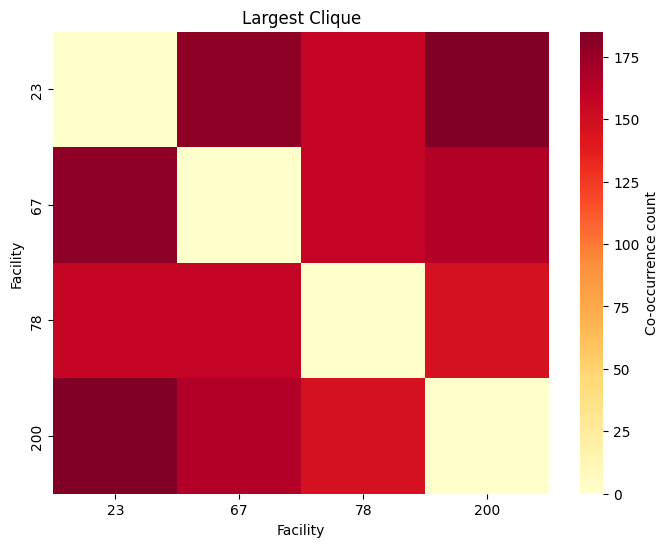

In [19]:
if cliques:
    largest_clique = min(cliques, key=best_clique)

    clique_subgraph = np.zeros(
        (
            len(largest_clique),
            len(largest_clique)
        )
    )

    for i, node_i in enumerate(largest_clique):
        for j, node_j in enumerate(largest_clique):
            clique_subgraph[i, j] = adjacency_matrix[node_i, node_j]

    plt.figure(figsize=(8, 6))

    sns.heatmap(clique_subgraph           ,
                xticklabels=largest_clique,
                yticklabels=largest_clique,
                cmap    ='YlOrRd',
                cbar_kws={'label': 'Co-occurrence count'})

    plt.title (f"Largest Clique")
    plt.xlabel("Facility")
    plt.ylabel("Facility")

    plt.show()

#### GREEDY DENSEST SUBGRAPH DETECTION

This section identifies the **densest subgraph** of the facility co-occurrence network using a greedy peeling algorithm.

The method iteratively removes the node with the lowest weighted degree and tracks the subset of nodes that maximizes average internal edge weight (density). Unlike cliques, which require full pairwise connectivity, the densest subgraph captures a strongly interconnected structural core without requiring complete connectivity.

The resulting subgraph represents the most cohesive backbone of the near-optimal solution landscape. It highlights a group of facilities that consistently co-occur with high intensity, revealing a robust structural nucleus of the network.

In [20]:
def densest_subgraph_greedy(adjacency_matrix, min_size=3):
    n = adjacency_matrix.shape[0]

    remaining     = set(range(n))
    best_subgraph = set()
    best_density  = 0

    while len(remaining) >= min_size:
        subgraph_array = adjacency_matrix[
            np.ix_(
                sorted(remaining),
                sorted(remaining)
            )
        ]

        current_weight  = np.sum(subgraph_array) / 2
        current_density = current_weight / len(remaining)

        if current_density > best_density:
            best_subgraph = remaining.copy()
            best_density  = current_density

        min_degree = float('inf')
        min_node   = None

        for node in remaining:
            degree = sum(
                adjacency_matrix[node, j]
                for j in remaining
                if  j != node
            )

            if degree < min_degree:
                min_degree = degree
                min_node   = node

        if min_node is not None:
            remaining.remove(min_node)
        else:
            break

    return best_subgraph, best_density

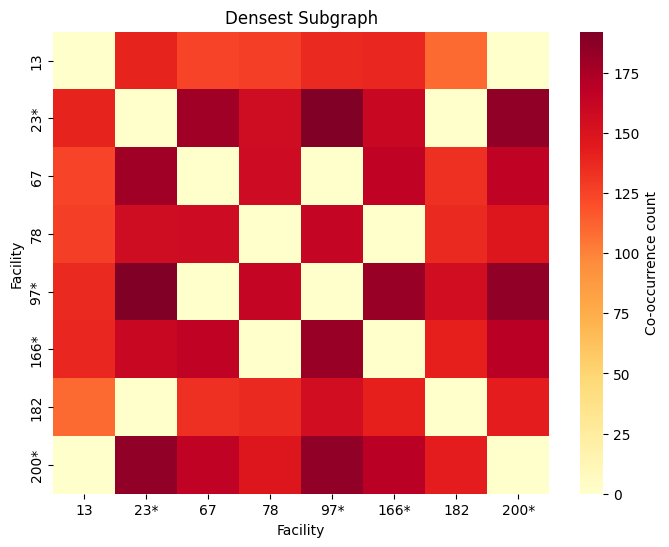

In [21]:
densest_nodes, _ = densest_subgraph_greedy(
    adjacency_matrix, min_size=3
)

densest_nodes_sorted    = sorted(list(densest_nodes))
densest_subgraph_matrix = adjacency_matrix[
    np.ix_(
        densest_nodes_sorted,
        densest_nodes_sorted
    )
]

tick_labels = [
    f"{node}*" if node in best_set else f"{node}"
    for node in densest_nodes_sorted
]


plt.figure(figsize=(8, 6))

sns.heatmap(densest_subgraph_matrix,
            xticklabels=tick_labels,
            yticklabels=tick_labels,
            cmap    ='YlOrRd',
            cbar_kws={'label': 'Co-occurrence count'})

plt.title (f"Densest Subgraph")
plt.xlabel("Facility")
plt.ylabel("Facility")

plt.show()